# Practice for Aggregating, Reshaping, and Combining Dataframes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Load customer demographics and claims information into separate dataframes:
- customer demographics should be loaded into `cust_df` from 'cust_demographics.csv'
- claims should be loaded into `claims_df` from 'claims.csv'

In [2]:
cust_df = pd.read_csv('cust_demographics.csv')
claims_df = pd.read_csv('claims.csv')

2. Inspect the DataFrames to get an understanding of the data, dtypes, and column structure

In [3]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CUST_ID      1087 non-null   int64 
 1   gender       1087 non-null   object
 2   DateOfBirth  1087 non-null   object
 3   State        1087 non-null   object
 4   Contact      1087 non-null   object
 5   Segment      1087 non-null   object
dtypes: int64(1), object(5)
memory usage: 51.1+ KB


In [4]:
claims_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1104 entries, 0 to 1103
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   claim_id             1104 non-null   int64 
 1   customer_id          1104 non-null   int64 
 2   incident_cause       1104 non-null   object
 3   claim_date           1104 non-null   object
 4   claim_area           1104 non-null   object
 5   police_report        1104 non-null   object
 6   claim_type           1104 non-null   object
 7   claim_amount         1100 non-null   object
 8   total_policy_claims  1104 non-null   int64 
 9   fraudulent           1104 non-null   object
dtypes: int64(3), object(7)
memory usage: 86.4+ KB


3. Check for duplicates and then remove them:

In [5]:
print("There are " + str(claims_df.duplicated().sum()) +  " duplicates in the claims dataset")
print("There are " + str(cust_df.duplicated().sum()) +  " duplicates in the customer dataset")

There are 4 duplicates in the claims dataset
There are 2 duplicates in the customer dataset


In [6]:
claims_df = claims_df.drop_duplicates()
cust_df = cust_df.drop_duplicates()

print("Now there are " + str(claims_df.duplicated().sum()) +  " duplicates in the claims dataset")

print("Now there are " + str(cust_df.duplicated().sum()) +  " duplicates in the customer dataset")

Now there are 0 duplicates in the claims dataset
Now there are 0 duplicates in the customer dataset


4. Join the dataframes and save to a dataframe `combined_df`. Identify what column(s) you will join on and then use an inner join. Drop any redundant columns resulting from merge:

In [7]:
combined_df = pd.merge(cust_df, claims_df, how='inner', left_on='CUST_ID', right_on='customer_id')
combined_df.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1,No
1,75740424,Female,13-Jan-70,ME,265-543-1264,Silver,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3,No
2,30308357,Female,11-Mar-84,TN,798-631-4758,Silver,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1,Yes
3,30308357,Female,11-Mar-84,TN,798-631-4758,Silver,63017412,30308357,Driver error,04/04/2018,Auto,No,Material only,$1950,6,No
4,47830476,Female,01-May-86,MA,413-187-7945,Silver,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1,No


In [8]:
#drop the redundant columns
combined_df = combined_df.drop(columns='customer_id')
combined_df.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum,54004764,Driver error,11/27/2017,Auto,No,Material only,$2980,1,No
1,75740424,Female,13-Jan-70,ME,265-543-1264,Silver,33985796,Crime,10/03/2018,Home,Unknown,Material only,$2980,3,No
2,30308357,Female,11-Mar-84,TN,798-631-4758,Silver,53522022,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1,Yes
3,30308357,Female,11-Mar-84,TN,798-631-4758,Silver,63017412,Driver error,04/04/2018,Auto,No,Material only,$1950,6,No
4,47830476,Female,01-May-86,MA,413-187-7945,Silver,13015401,Natural causes,06/17/2018,Auto,No,Material only,$1680,1,No


5. Identify cleaning tasks in the `claim_amount` column and execute them:

In [9]:
combined_df['claim_amount'].head() #we have nulls, formatted to string

0      $2980
1      $2980
2    $3369.5
3      $1950
4      $1680
Name: claim_amount, dtype: object

In [10]:
#remove dollar sign and convert to floats
combined_df['claim_amount'] = combined_df['claim_amount'].str.replace('$', '').astype('float')
combined_df['claim_amount'].head()

0    2980.0
1    2980.0
2    3369.5
3    1950.0
4    1680.0
Name: claim_amount, dtype: float64

In [11]:
#drop NaNs
combined_df= combined_df.dropna(subset=['claim_amount'])

In [12]:
combined_df['claim_amount'].isna().sum()

0

6. Clean fradulent and convert to appropriate numeric values:

In [13]:
# check category value counts
print(combined_df['fraudulent'].value_counts())

# create boolean and convert to binary integer encoding
combined_df['fraudulent'] = (combined_df['fraudulent'] == 'Yes').astype('int')


fraudulent
No     834
Yes    247
Name: count, dtype: int64


In [14]:
combined_df['fraudulent'].value_counts()

fraudulent
0    834
1    247
Name: count, dtype: int64

7. Use an appropriate plot to visualize the the mean claim amount for each incidence cause:

In [15]:
cause_dependence = combined_df.groupby('incident_cause')[['claim_amount','fraudulent']].mean(numeric_only=True)
cause_dependence

,claim_amount,fraudulent
incident_cause,,
Crime,6546.564815,0.240741
Driver error,13756.873077,0.226923
Natural causes,7308.886486,0.210811
Other causes,14570.896491,0.249123
Other driver error,14720.043210,0.213992


<BarContainer object of 5 artists>

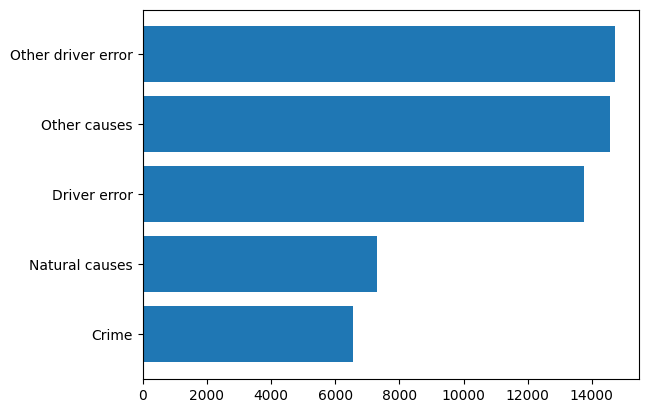

In [16]:
fig, ax = plt.subplots()
clm_amount = cause_dependence['claim_amount'].sort_values(ascending=True)
ax.barh(clm_amount.index ,clm_amount.values)

In [17]:
clm_amount

incident_cause
Crime                  6546.564815
Natural causes         7308.886486
Driver error          13756.873077
Other causes          14570.896491
Other driver error    14720.043210
Name: claim_amount, dtype: float64

8. Plot the distribution of claim amounts: use a histogram.

(array([486., 164.,   0.,   0.,   0.,   0.,   0.,   2.,  18.,  20.,  25.,
         29.,  30.,  24.,  18.,  23.,  27.,  21.,  28.,  21.,  32.,  25.,
         21.,  20.,  16.,  12.,   4.,   7.,   3.,   5.]),
 array([ 1000.        ,  2571.68333333,  4143.36666667,  5715.05      ,
         7286.73333333,  8858.41666667, 10430.1       , 12001.78333333,
        13573.46666667, 15145.15      , 16716.83333333, 18288.51666667,
        19860.2       , 21431.88333333, 23003.56666667, 24575.25      ,
        26146.93333333, 27718.61666667, 29290.3       , 30861.98333333,
        32433.66666667, 34005.35      , 35577.03333333, 37148.71666667,
        38720.4       , 40292.08333333, 41863.76666667, 43435.45      ,
        45007.13333333, 46578.81666667, 48150.5       ]),
 <BarContainer object of 30 artists>)

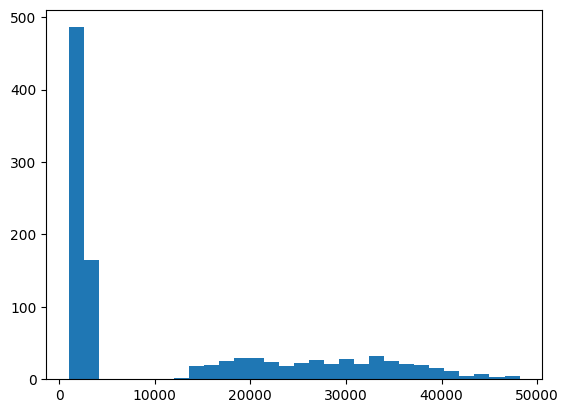

In [18]:
fig, ax = plt.subplots()
ax.hist(combined_df['claim_amount'], bins=30)

9. There is a bimodal distribution here. Create a binary column called "claim_size" that is "large" when the claim amount is greater than or equal to 10000 and "small" otherwise. We will use this binary categorical later.

In [19]:
combined_df['claim_size'] = (combined_df['claim_amount'] >= 10000).map({True: 'large', False: 'small'})

combined_df.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,claim_size
0,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum,54004764,Driver error,11/27/2017,Auto,No,Material only,2980.0,1,0,small
1,75740424,Female,13-Jan-70,ME,265-543-1264,Silver,33985796,Crime,10/03/2018,Home,Unknown,Material only,2980.0,3,0,small
2,30308357,Female,11-Mar-84,TN,798-631-4758,Silver,53522022,Other driver error,02/02/2018,Auto,No,Material only,3369.5,1,1,small
3,30308357,Female,11-Mar-84,TN,798-631-4758,Silver,63017412,Driver error,04/04/2018,Auto,No,Material only,1950.0,6,0,small
4,47830476,Female,01-May-86,MA,413-187-7945,Silver,13015401,Natural causes,06/17/2018,Auto,No,Material only,1680.0,1,0,small


10. Investigate the fraudulent claim rate by state:
- get the rate of fraudulent claims by state sorted in descending order. Save this to a Series `sorted_rates`
- get the states with the top 15 fraudulent claim rates and save this list of state to `state_names`.

In [20]:
sorted_rates = combined_df.groupby('State')['fraudulent'].mean(numeric_only=True).sort_values(ascending=False)
state_names = sorted_rates[0:15].index
print(sorted_rates[0:15])
state_names

State
TN    0.555556
KY    0.428571
MT    0.400000
NM    0.368421
OR    0.357143
CA    0.352941
WI    0.347826
DE    0.344828
ID    0.333333
MI    0.333333
TX    0.318182
WV    0.300000
WY    0.294118
AL    0.285714
MA    0.269231
Name: fraudulent, dtype: float64


Index(['TN', 'KY', 'MT', 'NM', 'OR', 'CA', 'WI', 'DE', 'ID', 'MI', 'TX', 'WV',
       'WY', 'AL', 'MA'],
      dtype='object', name='State')

11. It would be interesting to see whether there is a differentiation of fraud rates by claim size in each state. First compute this by using a pivot table. Display results from the states with the top 15 highest fraudulent claim rates.


In [21]:
widestateclaims = combined_df.pivot_table(index = 'State', columns='claim_size', values='fraudulent')
widestateclaims.loc[state_names]

claim_size,large,small
State,,
TN,0.444444,0.611111
KY,0.333333,0.454545
MT,0.416667,0.375000
NM,0.333333,0.400000
OR,0.200000,0.444444
CA,0.375000,0.333333
WI,0.300000,0.384615
DE,0.333333,0.352941
ID,0.400000,0.294118


12. Conduct a groupby/aggregation(s) by State and claim size. This time you will compute the fraudulent claim rate as well as the number of examples in each category and subcategory. The result should be presented in a single DataFrame.

*Hint*: you can compute each aggregation separately and then concatenate **or** you can look up how to perform multiple aggregations with the .agg() method.

In [22]:
groupedstateclaims_mean = combined_df.groupby(['State', 'claim_size'])['fraudulent'].mean().rename('fraud_rate')
groupedstateclaims_count = combined_df.groupby(['State', 'claim_size'])['fraudulent'].count().rename('count')

objs = [groupedstateclaims_count, groupedstateclaims_mean] 
groupedstateclaims = pd.concat(objs, axis=1) # side by side, column based concatenation
groupedstateclaims.head(10)

count  fraud_rate
State claim_size                   
AK    large           9    0.333333
      small          11    0.181818
AL    large          11    0.363636
      small          17    0.235294
AR    large           9    0.111111
      small          20    0.300000
AZ    large           8    0.250000
      small           7    0.000000
CA    large           8    0.375000
      small           9    0.333333

There are not too many examples within each subgroup -- but it is plausible that there are enough here to differentiate between fraud behavior for small and large claims in many of the states.


13. Plot fraudulent rates amongst small and large claim sizes in the 15 states with the top average fraudulent rates:
- put this in a single bar chart with large and small claim sizes overlayed on top of each other
- use blue for large claim and orange for small claim, set transparency parameter to 0.4.
- make sure that you label plots appropriately and display legends.

*Hint*: selecting the appropriate column and unstacking the results of your groubpy on State and claim size might be helpful here

In [23]:
#unstacking
#claim_fraud_state = groupedstateclaims.unstack('claim_size')['fraud_rate']
claim_fraud_state = groupedstateclaims.loc[state_names, 'fraud_rate'].unstack()


claim_size,large,small
State,,
TN,0.444444,0.611111
KY,0.333333,0.454545
MT,0.416667,0.375000
NM,0.333333,0.400000
OR,0.200000,0.444444
CA,0.375000,0.333333
WI,0.300000,0.384615
DE,0.333333,0.352941
ID,0.400000,0.294118


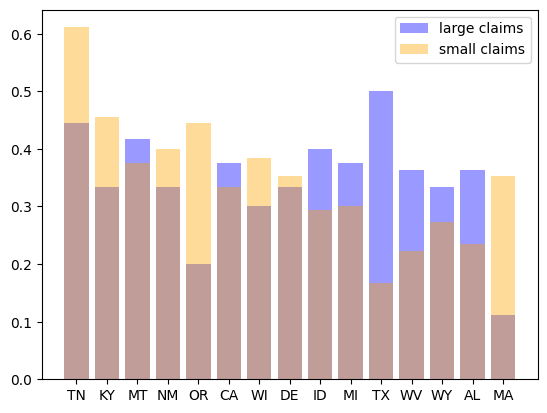

In [24]:
fig, ax = plt.subplots()
ax.bar(claim_fraud_state.index, claim_fraud_state['large'], color='b', alpha=0.4, label='large claims')
ax.bar(claim_fraud_state.index, claim_fraud_state['small'], color='orange', alpha=0.4, label='small claims')
ax.legend()
claim_fraud_state

14. Just because its a lot of fun and good for you, melt the pivot table with average fraudulent rates (pivoted on State and claim size) for the states with top 15 highest overall fradulent rates. We have recalculated the table that is to be melted below from `combined_df` and have stored it in `widestateclaims`:
- make sure that the index is still State (look up what option for melt you need)
- the value should be named 'fraud_rate'
- save to `melted_claims`

In [25]:

widestateclaims = combined_df.pivot_table(index='State', columns='claim_size', values='fraudulent').loc[state_names]
melted_claims = widestateclaims.melt(value_vars = ['large', 'small'], value_name = 'fraud_rate', ignore_index=False)
melted_claims.head()


,claim_size,fraud_rate
State,,
TN,large,0.444444
KY,large,0.333333
MT,large,0.416667
NM,large,0.333333
OR,large,0.200000


15. [optional] There are a lot of other aspects of the data that we have not touched. In particular, it might be interesting to look at how claimant age and gender influence claim behavior. You could also take a look at incident cause and whether a police report was filed or not in seeing how fraudulent claims and claim size are influenced by these two categorical classes. Knock yourself out and use your reshaping and visualization skills to explore.